# Model Stim Performances

comparing model performances on different stim combos

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.io
import os
import importlib
import sys
from collections import defaultdict

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
from bootstrap_method import *
import spect_utils as su
import trajectory_utils as tu

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate')
import model as mdl


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-03-18 12:49:49.696253: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-18 12:49:49.704593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-18 12:49:49.713566: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register facto

Instructions for updating:
non-resource variables are not supported in the long term


### get some params for the first few plots

In [2]:
normalize_ipscs = 1 # usually will be 1
lesion_connections = 0 # if not lesioning put 0, else 'ii' etc
longer_delay = '' # '' if standard delay (150), longer can be 200 or 250

models_types = ['good_models','bad_models']
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

# freqbands_list = ['theta','alpha','beta','gamma1','gamma2']
band_ranges = su.get_band_ranges()

In [3]:
# load a model to get trial times

for models_type in models_types:
    # load list of models
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    n_models = len(model_list)
    print(f'Total: {n_models} {models_type} models')

    for n_model, model_fname in enumerate(model_list):
        
        print(f'Loading model {n_model+1}/{n_models}...')
        model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
        
        break
    break

Total: 41 good_models models
Loading model 1/41...


In [4]:
# get necessary trial timing info 

ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***

times_rate = {
    'T': ipsc_data['T'][0][0],
    'stim_on': ipsc_data['stim_on'][0][0],
    'stim_dur': ipsc_data['stim_dur'][0][0],
    'delay': ipsc_data['delay'][0][0],
    'fs': 200,
}

# get trial times in real time (seconds)
times_real = {
    'stim1_on': times_rate['stim_on']/times_rate['fs'],
    'stim1_off': (times_rate['stim_on'] + times_rate['stim_dur'])/times_rate['fs'],
    'stim2_on': (times_rate['stim_on'] + times_rate['stim_dur'] + times_rate['delay'])/times_rate['fs'],
    'stim2_off': (times_rate['stim_on'] + 2*times_rate['stim_dur'] + times_rate['delay'])/times_rate['fs'],
}

# load spectral time data
t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))
times_fft = {
    'stim1_on': su.get_fft_time(times_real['stim1_on'], t),
    'stim1_off': su.get_fft_time(times_real['stim1_off'], t),
    'stim2_on': su.get_fft_time(times_real['stim2_on'], t),
    'stim2_off': su.get_fft_time(times_real['stim2_off'], t),
}

# adjust for x-axis labels
t_skip = 15

In [5]:
normalize_ipscs = 1 # usually will be 1
lesion_connections = 0 # if not lesioning put 0, else 'ii' etc. usually 0 here bc we're comparing good vs bad models
longer_delay = '' # '' if standard delay (150), longer can be 200, 250, 400

models_types = ['good_models','bad_models']
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

## just plot model preferred stim in general

### first calculate and save performance for diff stim (only run once)

In [7]:
# load a model to get trial times

models_types = ['good_models', 'bad_models']
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

all_perfs = []
n_trials_per_condition = 100
stim1s = [-1, 1]
stim2s = [-1, 1]
n_trials = int(n_trials_per_condition*len(stim1s)*len(stim2s))

for models_type in models_types:
    # load list of models
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    n_models = len(model_list)
    print(f'Total: {n_models} {models_type} models')

    eval_perfs = np.zeros((n_models, n_trials))
    trial_stim_labels = np.zeros((n_trials,2))
    resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
    eval_amp_threshold = 0.7
    for n_model, model_fname in enumerate(model_list):
        print(f'Evaluating model {n_model+1}/{n_models}...')
        model_path = os.path.join(models_dir, model_list[n_model])

        for i, stim1 in enumerate(stim1s):
            for j, stim2 in enumerate(stim2s):
                for k in range(n_trials_per_condition):
                    trial_idx = (i*len(stim2s)+j)*n_trials_per_condition + k
                    u, label = tu.generate_xor_type(settings['T'], settings['stim_on'], 
                                                 settings['stim_dur'], settings['delay'], stim1, stim2)
                    _, _, o, _ = mdl.eval_tf(model_dir=model_path, settings=settings, u=u, lesion='')
                    
                    trial_stim_labels[trial_idx,0] = stim1
                    trial_stim_labels[trial_idx,1] = stim2
        
                    if label == 'same':
                        if np.max(o[resp_onset:]) > eval_amp_threshold:
                            eval_perfs[n_model, trial_idx] = 1
                    else:
                        if np.min(o[resp_onset:]) < -eval_amp_threshold:
                            eval_perfs[n_model, trial_idx] = 1
        print(f'+1/+1 performance: {np.mean(eval_perfs[n_model, np.where((trial_stim_labels[:,0] == 1) & (trial_stim_labels[:,1] == 1))])}')
        print(f'+1/-1 performance: {np.mean(eval_perfs[n_model, np.where((trial_stim_labels[:,0] == 1) & (trial_stim_labels[:,1] == -1))])}')
        print(f'-1/+1 performance: {np.mean(eval_perfs[n_model, np.where((trial_stim_labels[:,0] == -1) & (trial_stim_labels[:,1] == 1))])}')
        print(f'-1/-1 performance: {np.mean(eval_perfs[n_model, np.where((trial_stim_labels[:,0] == -1) & (trial_stim_labels[:,1] == -1))])}')
                    
    all_perfs.append(eval_perfs)


Total: 41 good_models models
Evaluating model 1/41...
+1/+1 performance: 0.99
+1/-1 performance: 0.74
-1/+1 performance: 0.91
-1/-1 performance: 0.83
Evaluating model 2/41...
+1/+1 performance: 0.99
+1/-1 performance: 0.63
-1/+1 performance: 0.97
-1/-1 performance: 0.4
Evaluating model 3/41...
+1/+1 performance: 0.85
+1/-1 performance: 0.77
-1/+1 performance: 1.0
-1/-1 performance: 0.96
Evaluating model 4/41...
+1/+1 performance: 0.99
+1/-1 performance: 1.0
-1/+1 performance: 1.0
-1/-1 performance: 0.99
Evaluating model 5/41...
+1/+1 performance: 1.0
+1/-1 performance: 0.99
-1/+1 performance: 1.0
-1/-1 performance: 1.0
Evaluating model 6/41...
+1/+1 performance: 0.91
+1/-1 performance: 0.5
-1/+1 performance: 1.0
-1/-1 performance: 1.0
Evaluating model 7/41...
+1/+1 performance: 0.74
+1/-1 performance: 1.0
-1/+1 performance: 0.82
-1/-1 performance: 0.74
Evaluating model 8/41...
+1/+1 performance: 0.9
+1/-1 performance: 0.93
-1/+1 performance: 0.39
-1/-1 performance: 0.99
Evaluating mode

In [8]:
# save all_perfs and trial_stim_labels

for i, models_type in enumerate(models_types):
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    these_perfs = np.array(all_perfs[i])
    np.save(f'{results_dir}ratemodel_delay{settings["delay"]}_trialtype_perfs.npy', these_perfs)
    print(f'Saved {results_dir}ratemodel_delay{settings["delay"]}_trialtype_perfs.npy')
    np.save(f'{results_dir}ratemodel_delay{settings["delay"]}_trialtype_perfs_stimlabels.npy', trial_stim_labels)
    print(f'Saved {results_dir}ratemodel_delay{settings["delay"]}_trialtype_perfs_stimlabels.npy')
    print('')

Saved /scratch/spikeRNN/models/DMS_OSF/good_models/ratemodel_delay150_trialtype_perfs.npy
Saved /scratch/spikeRNN/models/DMS_OSF/good_models/ratemodel_delay150_trialtype_perfs_stimlabels.npy

Saved /scratch/spikeRNN/models/DMS_OSF/bad_models/ratemodel_delay150_trialtype_perfs.npy
Saved /scratch/spikeRNN/models/DMS_OSF/bad_models/ratemodel_delay150_trialtype_perfs_stimlabels.npy



### load saved performance data

In [7]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

In [8]:
# load saved data

all_perfs = []
for i, models_type in enumerate(models_types):
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    eval_perfs = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_trialtype_perfs.npy')
    all_perfs.append(eval_perfs)
    trial_stim_labels = np.load(f'{results_dir}ratemodel_delay{settings["delay"]}_trialtype_perfs_stimlabels.npy')
    print(f'Loaded {results_dir}ratemodel_delay{settings["delay"]}_trialtype_perfs.npy')
    print(f'Loaded {results_dir}ratemodel_delay{settings["delay"]}_trialtype_perfs_stimlabels.npy')
    print('')

Loaded /scratch/spikeRNN/models/DMS_OSF/good_models/ratemodel_delay150_trialtype_perfs.npy
Loaded /scratch/spikeRNN/models/DMS_OSF/good_models/ratemodel_delay150_trialtype_perfs_stimlabels.npy

Loaded /scratch/spikeRNN/models/DMS_OSF/bad_models/ratemodel_delay150_trialtype_perfs.npy
Loaded /scratch/spikeRNN/models/DMS_OSF/bad_models/ratemodel_delay150_trialtype_perfs_stimlabels.npy



### Performance

#### all stim combos performance

In [9]:
# reshape to calculate mean performance on each trial type

condition_names = []

n_trials_per_condition = 100
stim1s = [-1, 1]
stim2s = [-1, 1]
n_trials = int(n_trials_per_condition*len(stim1s)*len(stim2s))

trialtype_perfs = []
for i_type, models_type in enumerate(models_types): # good or bad models
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    
    model_trialtype_perfs = np.zeros((len(model_list), len(stim1s)*len(stim2s)))
    for i_model, model_fname in enumerate(model_list): # all of the models of this type

        model_perf = all_perfs[i_type][i_model]

        for i, stim1 in enumerate(stim1s):
            for j, stim2 in enumerate(stim2s):
                if (i_type == 0) & (i_model == 0):
                    condition_names.append(f'{stim1}/{stim2}')
                
                trial_idx = int(i*len(stim2s)+j)
                model_trialtype_perfs[i_model, trial_idx] = np.mean(model_perf[np.where((trial_stim_labels[:,0] == stim1) & (trial_stim_labels[:,1] == stim2))])
    trialtype_perfs.append(model_trialtype_perfs)

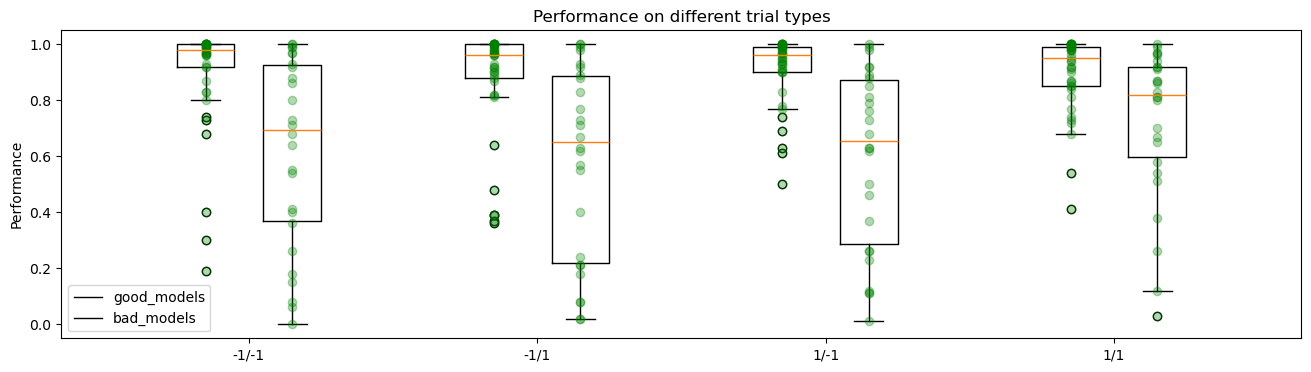

In [17]:
# plot performance results as paired box plot

plt.figure(figsize=(16,4))

sep = 0.15

for i, trialtype_perf in enumerate(trialtype_perfs):
    plt.boxplot(trialtype_perf, positions=np.arange(len(condition_names))+sep*(i*2-1), widths=0.2)
    
    for j in range(len(condition_names)):
        x = np.ones(trialtype_perf.shape[0])*j + sep*(i*2-1)
        y = trialtype_perf[:,j]
        plt.plot(x, y, 'o', color='g', alpha=0.3)

plt.xticks(np.arange(len(condition_names)), condition_names)
plt.ylabel('Performance')
plt.ylim([-0.05,1.05])
plt.title(f'Performance on different trial types')
plt.legend(models_types)
plt.show()

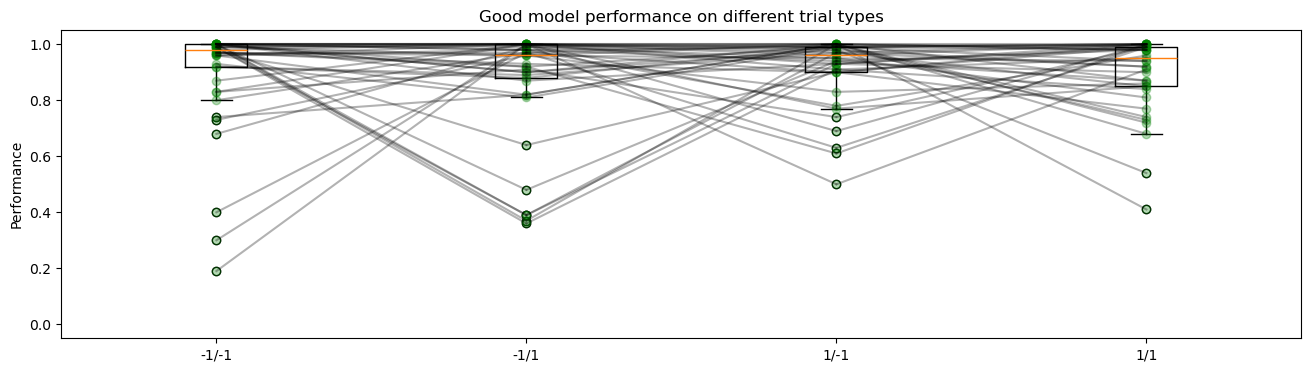

In [16]:
# plot just good model performances, with lines connecting across conditions

plt.figure(figsize=(16,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    if i == 0:
        plt.boxplot(trialtype_perf, positions=np.arange(len(condition_names)), widths=0.2)
        for j in range(len(condition_names)):
            x = np.ones(trialtype_perf.shape[0])*j
            y = trialtype_perf[:,j]
            plt.plot(x, y, 'o', color='g', alpha=0.3)
        for j in range(len(condition_names)-1):
            plt.plot([j,j+1], [trialtype_perf[:,j], trialtype_perf[:,j+1]], 'k-', alpha=0.3)

plt.xticks(np.arange(len(condition_names)), condition_names)
plt.ylabel('Performance')
plt.title(f'Good model performance on different trial types')
plt.ylim([-0.05,1.05])
plt.show()

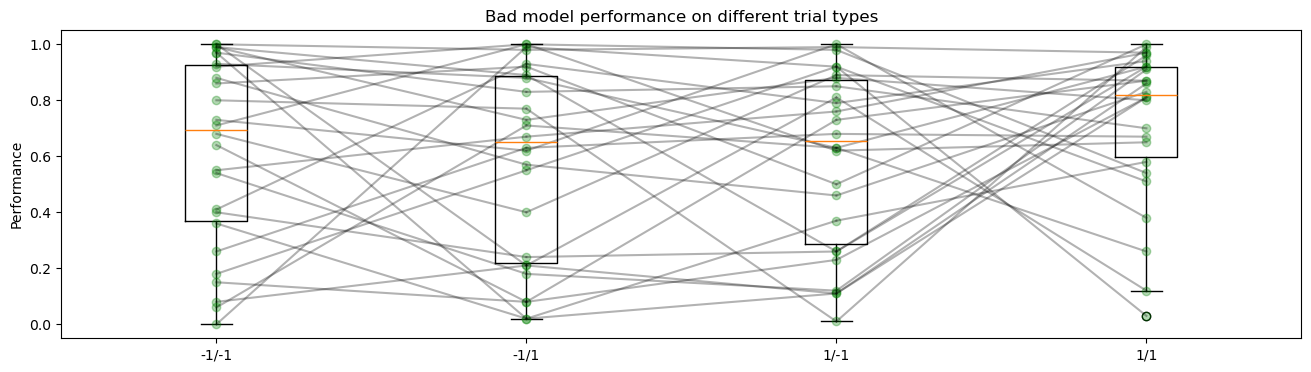

In [15]:
# plot just bad model performances, with lines connecting across conditions

plt.figure(figsize=(16,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    if i == 1:
        plt.boxplot(trialtype_perf, positions=np.arange(len(condition_names)), widths=0.2)
        for j in range(len(condition_names)):
            x = np.ones(trialtype_perf.shape[0])*j
            y = trialtype_perf[:,j]
            plt.plot(x, y, 'o', color='g', alpha=0.3)
        for j in range(len(condition_names)-1):
            plt.plot([j,j+1], [trialtype_perf[:,j], trialtype_perf[:,j+1]], 'k-', alpha=0.3)

plt.xticks(np.arange(len(condition_names)), condition_names)
plt.ylabel('Performance')
plt.ylim([-0.05,1.05])
plt.title(f'Bad model performance on different trial types')
plt.show()

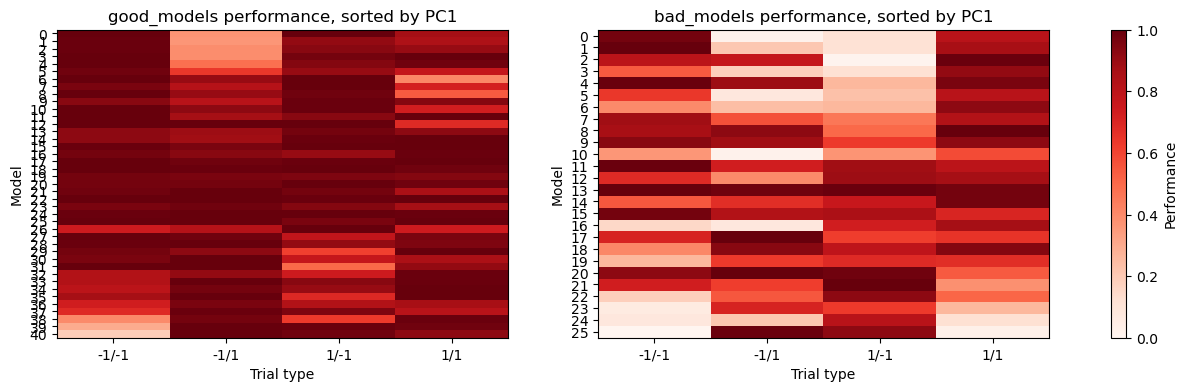

In [29]:
# sort by pca order

from sklearn.decomposition import PCA

fig, axs = plt.subplots(1,2,figsize=(16,4))
for i, models_type in enumerate(models_types):
    pca = PCA(n_components=2)
    trialtype_perfs_pca = pca.fit_transform(trialtype_perfs[i])
    sort_idx = np.argsort(trialtype_perfs_pca[:,0])
    trialtype_perfs_sorted = trialtype_perfs[i][sort_idx]

    axs[i].imshow(trialtype_perfs_sorted, aspect='auto', cmap='Reds', vmin=0, vmax=1)
    axs[i].set_xticks(np.arange(len(condition_names)))
    axs[i].set_xticklabels(condition_names)
    axs[i].set_yticks(np.arange(trialtype_perfs[i].shape[0]))
    axs[i].set_yticklabels(np.arange(trialtype_perfs[i].shape[0]))
    axs[i].set_title(f'{models_type} performance, sorted by PC1')
    axs[i].set_xlabel('Trial type')
    axs[i].set_ylabel('Model')
# get colorbar
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=0, vmax=1))
sm._A = []
cbar = plt.colorbar(sm, ax=axs)
cbar.set_label('Performance')
# plt.tight_layout()
plt.show()

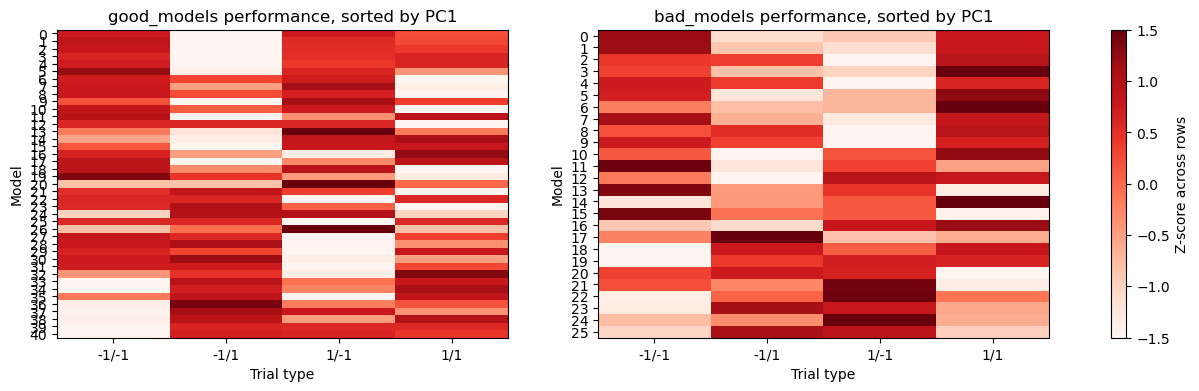

In [40]:
# sort by pca order (z-scoring)

fig, axs = plt.subplots(1,2,figsize=(16,4))
for i, models_type in enumerate(models_types):
    pca = PCA(n_components=2)
    trialtype_perfs_pca = pca.fit_transform(trialtype_perfs[i])
    sort_idx = np.argsort(trialtype_perfs_pca[:,0])
    trialtype_perfs_sorted = trialtype_perfs[i][sort_idx]

    axs[i].imshow(scipy.stats.zscore(trialtype_perfs_sorted, axis=1), aspect='auto', cmap='Reds', vmin=-1.5, vmax=1.5)
    axs[i].set_xticks(np.arange(len(condition_names)))
    axs[i].set_xticklabels(condition_names)
    axs[i].set_yticks(np.arange(trialtype_perfs[i].shape[0]))
    axs[i].set_yticklabels(np.arange(trialtype_perfs[i].shape[0]))
    axs[i].set_title(f'{models_type} performance, sorted by PC1')
    axs[i].set_xlabel('Trial type')
    axs[i].set_ylabel('Model')
# get colorbar
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=-1.5, vmax=1.5))
sm._A = []
cbar = plt.colorbar(sm, ax=axs)
cbar.set_label('Z-score across rows')
# plt.tight_layout()
plt.show()

#### stim1 performances

In [75]:
# reshape to calculate mean performance on each trial type

condition_names = []

n_trials_per_condition = 100
stim1s = [-1, 1]
stim2s = [-1, 1]
n_trials = int(n_trials_per_condition*len(stim1s)*len(stim2s))

trialtype_perfs = []
for i_type, models_type in enumerate(models_types): # good or bad models
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    
    model_trialtype_perfs = np.zeros((len(model_list), len(stim1s)))
    for i_model, model_fname in enumerate(model_list): # all of the models of this type

        model_perf = all_perfs[i_type][i_model]

        for i, stim1 in enumerate(stim1s):
            if (i_type == 0) & (i_model == 0):
                condition_names.append(f'{stim1}')
                
            model_trialtype_perfs[i_model, i] = np.mean(model_perf[np.where((trial_stim_labels[:,0] == stim1))])
    trialtype_perfs.append(model_trialtype_perfs)
print(condition_names)
print(trialtype_perfs[0].shape)
print(trialtype_perfs[1].shape)

['-1', '1']
(41, 2)
(26, 2)


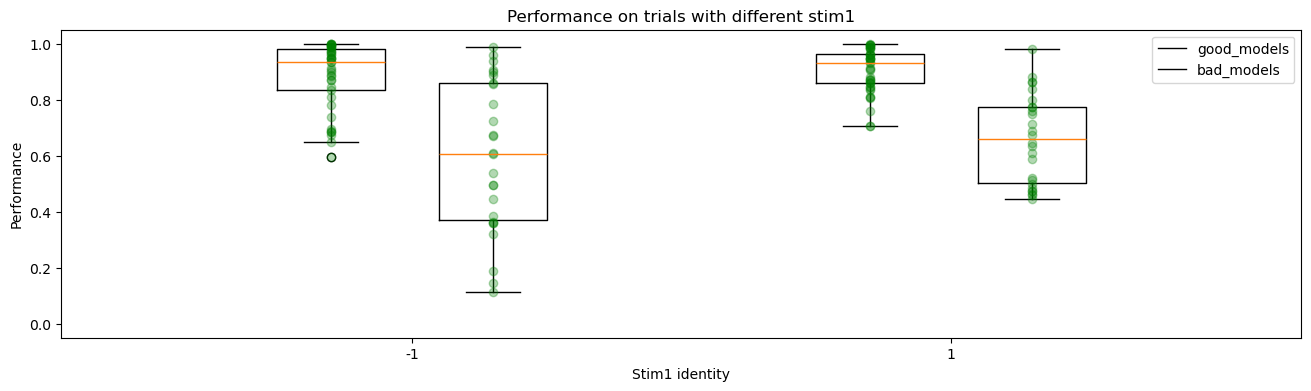

In [76]:
# plot performance results as paired box plot

plt.figure(figsize=(16,4))

sep = 0.15

for i, trialtype_perf in enumerate(trialtype_perfs):
    plt.boxplot(trialtype_perf, positions=np.arange(len(condition_names))+sep*(i*2-1), widths=0.2)
    
    for j in range(len(condition_names)):
        x = np.ones(trialtype_perf.shape[0])*j + sep*(i*2-1)
        y = trialtype_perf[:,j]
        plt.plot(x, y, 'o', color='g', alpha=0.3)

plt.xticks(np.arange(len(condition_names)), condition_names)
plt.ylabel('Performance')
plt.ylim([-0.05,1.05])
plt.title(f'Performance on trials with different stim1')
plt.xlabel('Stim1 identity')
plt.legend(models_types)
plt.show()

p-value for stim1 -1 vs 1: 0.5390588894279823


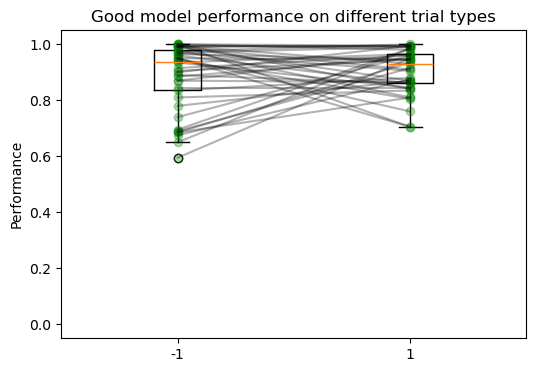

In [83]:
# plot just good model performances, with lines connecting across conditions

plt.figure(figsize=(6,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    if i == 0:
        plt.boxplot(trialtype_perf, positions=np.arange(len(condition_names)), widths=0.2)
        for j in range(len(condition_names)):
            x = np.ones(trialtype_perf.shape[0])*j
            y = trialtype_perf[:,j]
            plt.plot(x, y, 'o', color='g', alpha=0.3)
        for j in range(len(condition_names)-1):
            plt.plot([j,j+1], [trialtype_perf[:,j], trialtype_perf[:,j+1]], 'k-', alpha=0.3)

# signrank test
for j in range(len(condition_names)-1):
    _, pval = scipy.stats.wilcoxon(trialtype_perfs[0][:,j], trialtype_perfs[0][:,j+1])
    print(f'p-value for stim1 {condition_names[j]} vs {condition_names[j+1]}: {pval}')


plt.xticks(np.arange(len(condition_names)), condition_names)
plt.ylabel('Performance')
plt.title(f'Good model performance on different trial types')
plt.ylim([-0.05,1.05])
plt.show()

p-value for stim1 -1 vs 1: 0.5390588894279823


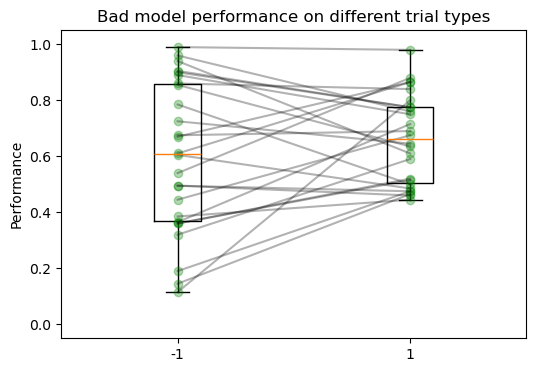

In [82]:
# plot just bad model performances, with lines connecting across conditions

plt.figure(figsize=(6,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    if i == 1:
        plt.boxplot(trialtype_perf, positions=np.arange(len(condition_names)), widths=0.2)
        for j in range(len(condition_names)):
            x = np.ones(trialtype_perf.shape[0])*j
            y = trialtype_perf[:,j]
            plt.plot(x, y, 'o', color='g', alpha=0.3)
        for j in range(len(condition_names)-1):
            plt.plot([j,j+1], [trialtype_perf[:,j], trialtype_perf[:,j+1]], 'k-', alpha=0.3)

# signrank test
for j in range(len(condition_names)-1):
    _, pval = scipy.stats.wilcoxon(trialtype_perfs[0][:,j], trialtype_perfs[0][:,j+1])
    print(f'p-value for stim1 {condition_names[j]} vs {condition_names[j+1]}: {pval}')

plt.xticks(np.arange(len(condition_names)), condition_names)
plt.ylabel('Performance')
plt.ylim([-0.05,1.05])
plt.title(f'Bad model performance on different trial types')
plt.show()

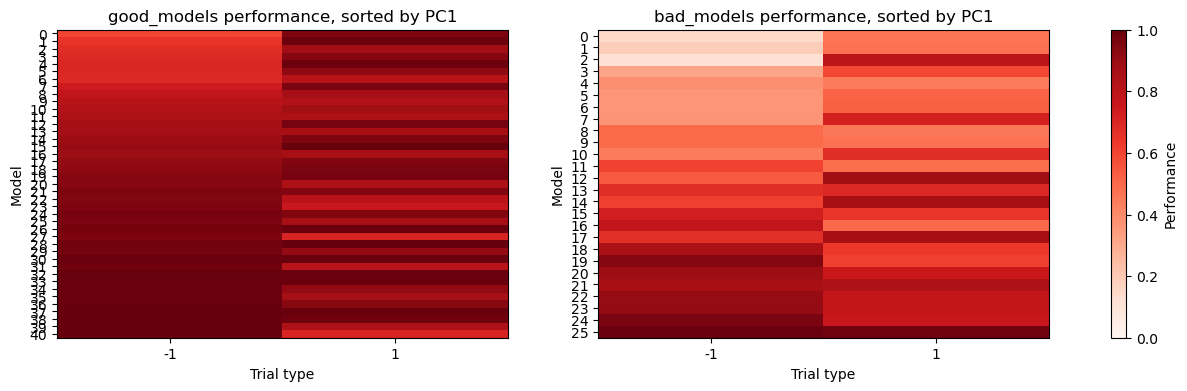

In [79]:
# sort by pca order

from sklearn.decomposition import PCA

fig, axs = plt.subplots(1,2,figsize=(16,4))
for i, models_type in enumerate(models_types):
    pca = PCA(n_components=2)
    trialtype_perfs_pca = pca.fit_transform(trialtype_perfs[i])
    sort_idx = np.argsort(trialtype_perfs_pca[:,0])
    trialtype_perfs_sorted = trialtype_perfs[i][sort_idx]

    axs[i].imshow(trialtype_perfs_sorted, aspect='auto', cmap='Reds', vmin=0, vmax=1)
    axs[i].set_xticks(np.arange(len(condition_names)))
    axs[i].set_xticklabels(condition_names)
    axs[i].set_yticks(np.arange(trialtype_perfs[i].shape[0]))
    axs[i].set_yticklabels(np.arange(trialtype_perfs[i].shape[0]))
    axs[i].set_title(f'{models_type} performance, sorted by PC1')
    axs[i].set_xlabel('Trial type')
    axs[i].set_ylabel('Model')
# get colorbar
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=0, vmax=1))
sm._A = []
cbar = plt.colorbar(sm, ax=axs)
cbar.set_label('Performance')
# plt.tight_layout()
plt.show()

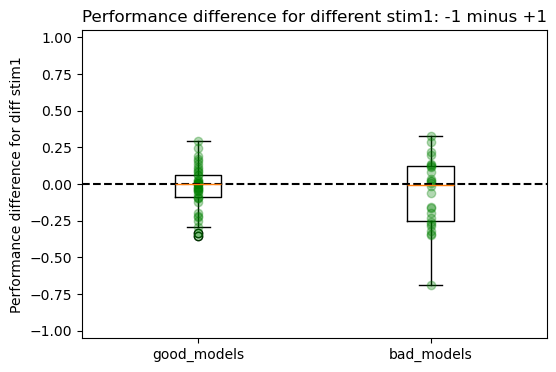

In [84]:
# plot boxplot, difference between stim for good models and bad models

plt.figure(figsize=(6,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    dif = trialtype_perf[:,0] - trialtype_perf[:,1]
    plt.boxplot(dif, positions=[i], widths=0.2)
    plt.plot(np.ones(len(dif))*i, dif, 'o', color='g', alpha=0.3)

plt.axhline(0, color='k', linestyle='--')
plt.xticks([0,1], models_types)
plt.ylabel('Performance difference for diff stim1')
plt.title(f'Performance difference for different stim1: -1 minus +1')
plt.ylim([-1.05,1.05])
plt.show()


p-value for good_models: 0.5390588894279823
p-value for bad_models: 0.28038380599577895


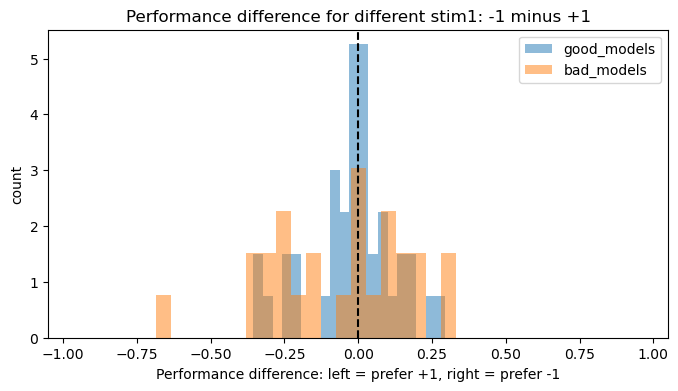

In [81]:
# plot as histograms

# plot boxplot, difference between stim for good models and bad models

plt.figure(figsize=(8,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    dif = trialtype_perf[:,0] - trialtype_perf[:,1]
    plt.hist(dif, bins=20, alpha=0.5, label=models_types[i], density=True)

    # calc wilcoxon difference from 0
    _, pval = scipy.stats.wilcoxon(dif)
    print(f'p-value for {models_types[i]}: {pval}')

plt.axvline(0, color='k', linestyle='--')
# plt.xticks([0,1], models_types)
plt.ylabel('count')
plt.xlabel('Performance difference: left = prefer +1, right = prefer -1')
plt.title(f'Performance difference for different stim1: -1 minus +1')
plt.legend()
plt.xlim([-1.05,1.05])
plt.show()


#### match/mismatch performances

In [85]:
# reshape to calculate mean performance on each trial type

condition_names = ['match','mismatch']

trialtype_perfs = []
for i_type, models_type in enumerate(models_types): # good or bad models
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    
    model_trialtype_perfs = np.zeros((len(model_list), len(stim1s)))
    for i_model, model_fname in enumerate(model_list): # all of the models of this type

        model_perf = all_perfs[i_type][i_model]
        
        model_trialtype_perfs[i_model, 0] = np.mean(model_perf[np.where((trial_stim_labels[:,0] != trial_stim_labels[:,1]))]) #match
        model_trialtype_perfs[i_model, 1] = np.mean(model_perf[np.where((trial_stim_labels[:,0] == trial_stim_labels[:,1]))]) #mismatch

    trialtype_perfs.append(model_trialtype_perfs)
print(condition_names)
print(trialtype_perfs[0].shape)
print(trialtype_perfs[1].shape)

['match', 'mismatch']
(41, 2)
(26, 2)


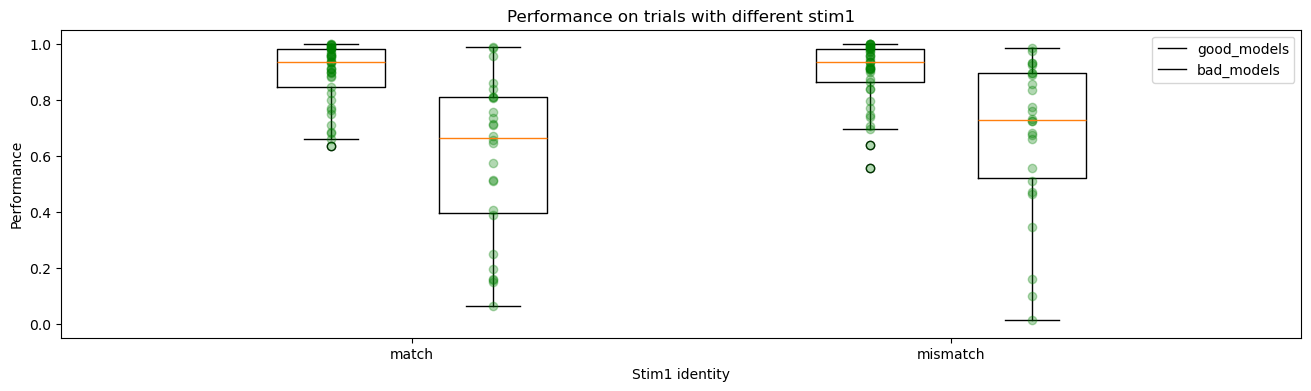

In [86]:
# plot performance results as paired box plot

plt.figure(figsize=(16,4))

sep = 0.15

for i, trialtype_perf in enumerate(trialtype_perfs):
    plt.boxplot(trialtype_perf, positions=np.arange(len(condition_names))+sep*(i*2-1), widths=0.2)
    
    for j in range(len(condition_names)):
        x = np.ones(trialtype_perf.shape[0])*j + sep*(i*2-1)
        y = trialtype_perf[:,j]
        plt.plot(x, y, 'o', color='g', alpha=0.3)

plt.xticks(np.arange(len(condition_names)), condition_names)
plt.ylabel('Performance')
plt.ylim([-0.05,1.05])
plt.title(f'Performance on trials with different stim1')
plt.xlabel('Stim1 identity')
plt.legend(models_types)
plt.show()

p-value for stim1 match vs mismatch: 0.7571650530186803


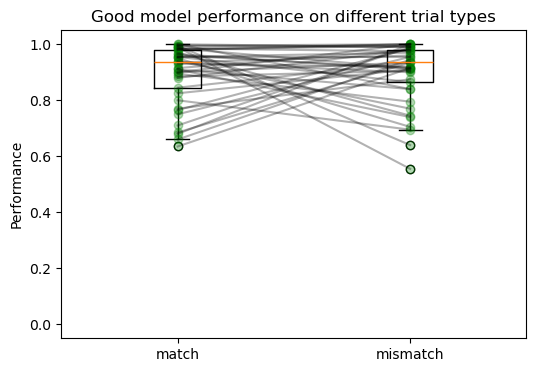

In [88]:
# plot just good model performances, with lines connecting across conditions

plt.figure(figsize=(6,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    if i == 0:
        plt.boxplot(trialtype_perf, positions=np.arange(len(condition_names)), widths=0.2)
        for j in range(len(condition_names)):
            x = np.ones(trialtype_perf.shape[0])*j
            y = trialtype_perf[:,j]
            plt.plot(x, y, 'o', color='g', alpha=0.3)
        for j in range(len(condition_names)-1):
            plt.plot([j,j+1], [trialtype_perf[:,j], trialtype_perf[:,j+1]], 'k-', alpha=0.3)

# signrank test
for j in range(len(condition_names)-1):
    _, pval = scipy.stats.wilcoxon(trialtype_perfs[0][:,j], trialtype_perfs[0][:,j+1])
    print(f'p-value for stim1 {condition_names[j]} vs {condition_names[j+1]}: {pval}')


plt.xticks(np.arange(len(condition_names)), condition_names)
plt.ylabel('Performance')
plt.title(f'Good model performance on different trial types')
plt.ylim([-0.05,1.05])
plt.show()

p-value for stim1 match vs mismatch: 0.7571650530186803


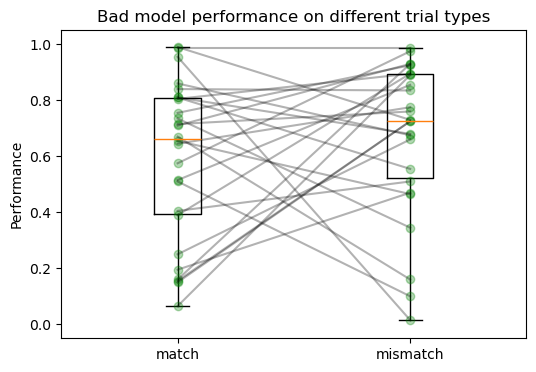

In [89]:
# plot just bad model performances, with lines connecting across conditions

plt.figure(figsize=(6,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    if i == 1:
        plt.boxplot(trialtype_perf, positions=np.arange(len(condition_names)), widths=0.2)
        for j in range(len(condition_names)):
            x = np.ones(trialtype_perf.shape[0])*j
            y = trialtype_perf[:,j]
            plt.plot(x, y, 'o', color='g', alpha=0.3)
        for j in range(len(condition_names)-1):
            plt.plot([j,j+1], [trialtype_perf[:,j], trialtype_perf[:,j+1]], 'k-', alpha=0.3)

# signrank test
for j in range(len(condition_names)-1):
    _, pval = scipy.stats.wilcoxon(trialtype_perfs[0][:,j], trialtype_perfs[0][:,j+1])
    print(f'p-value for stim1 {condition_names[j]} vs {condition_names[j+1]}: {pval}')

plt.xticks(np.arange(len(condition_names)), condition_names)
plt.ylabel('Performance')
plt.ylim([-0.05,1.05])
plt.title(f'Bad model performance on different trial types')
plt.show()

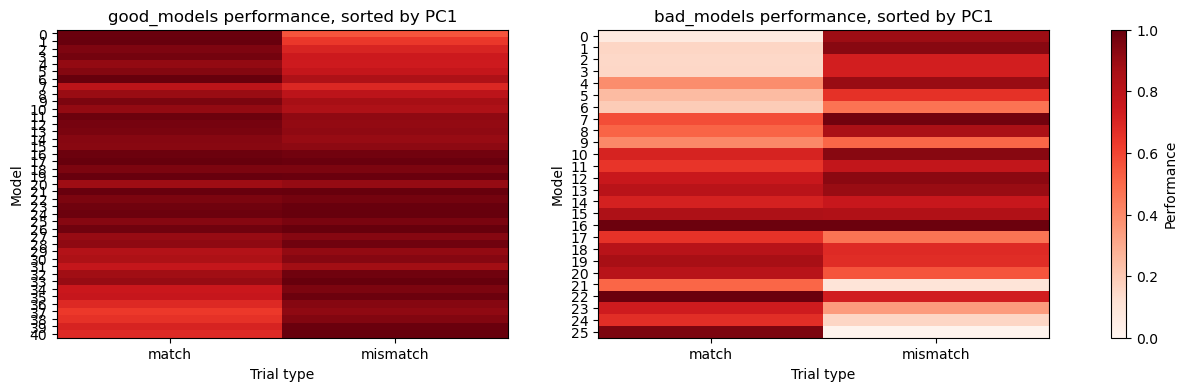

In [90]:
# sort by pca order

from sklearn.decomposition import PCA

fig, axs = plt.subplots(1,2,figsize=(16,4))
for i, models_type in enumerate(models_types):
    pca = PCA(n_components=2)
    trialtype_perfs_pca = pca.fit_transform(trialtype_perfs[i])
    sort_idx = np.argsort(trialtype_perfs_pca[:,0])
    trialtype_perfs_sorted = trialtype_perfs[i][sort_idx]

    axs[i].imshow(trialtype_perfs_sorted, aspect='auto', cmap='Reds', vmin=0, vmax=1)
    axs[i].set_xticks(np.arange(len(condition_names)))
    axs[i].set_xticklabels(condition_names)
    axs[i].set_yticks(np.arange(trialtype_perfs[i].shape[0]))
    axs[i].set_yticklabels(np.arange(trialtype_perfs[i].shape[0]))
    axs[i].set_title(f'{models_type} performance, sorted by PC1')
    axs[i].set_xlabel('Trial type')
    axs[i].set_ylabel('Model')
# get colorbar
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=0, vmax=1))
sm._A = []
cbar = plt.colorbar(sm, ax=axs)
cbar.set_label('Performance')
# plt.tight_layout()
plt.show()

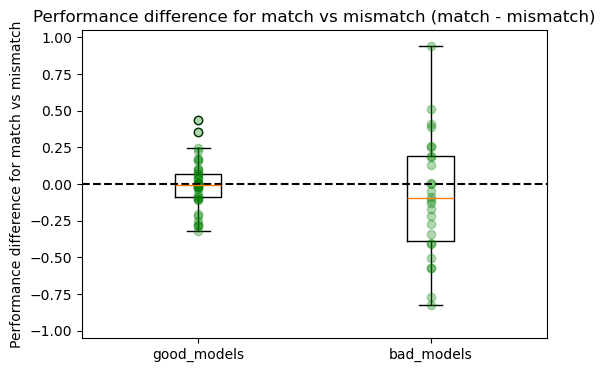

In [93]:
# plot boxplot, difference between stim for good models and bad models

plt.figure(figsize=(6,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    dif = trialtype_perf[:,0] - trialtype_perf[:,1]
    plt.boxplot(dif, positions=[i], widths=0.2)
    plt.plot(np.ones(len(dif))*i, dif, 'o', color='g', alpha=0.3)

plt.axhline(0, color='k', linestyle='--')
plt.xticks([0,1], models_types)
plt.ylabel('Performance difference for match vs mismatch')
plt.title(f'Performance difference for match vs mismatch (match - mismatch)')
plt.ylim([-1.05,1.05])
plt.show()


p-value for good_models: 0.7571650530186803
p-value for bad_models: 0.3001975409294876


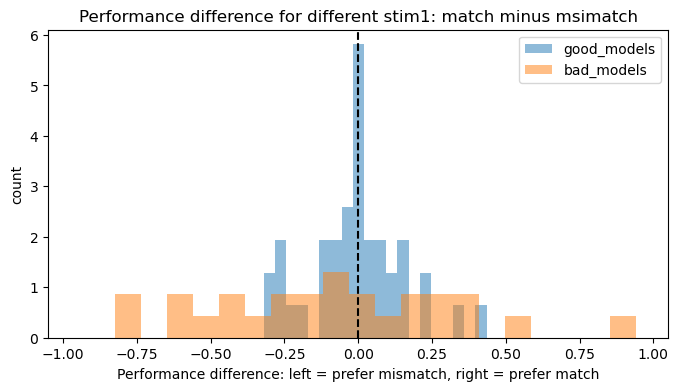

In [94]:
# plot as histograms

# plot boxplot, difference between stim for good models and bad models

plt.figure(figsize=(8,4))

for i, trialtype_perf in enumerate(trialtype_perfs):
    dif = trialtype_perf[:,0] - trialtype_perf[:,1]
    plt.hist(dif, bins=20, alpha=0.5, label=models_types[i], density=True)

    # calc wilcoxon difference from 0
    _, pval = scipy.stats.wilcoxon(dif)
    print(f'p-value for {models_types[i]}: {pval}')

plt.axvline(0, color='k', linestyle='--')
# plt.xticks([0,1], models_types)
plt.ylabel('count')
plt.xlabel('Performance difference: left = prefer mismatch, right = prefer match')
plt.title(f'Performance difference for different stim1: match minus msimatch')
plt.legend()
plt.xlim([-1.05,1.05])
plt.show()


### Preferences

#### all stim combos preference

In [ ]:
# plot stim combo preference



#### stim1 preference

In [ ]:
# plot stim1 preference



#### match/mismatch preference

In [ ]:
# plot match / mismatch preference

